# Bitcoin Market Sentiment and Trader Performance Analysis
This notebook explores the relationship between trader performance (from Hyperliquid historical data) and Bitcoin market sentiment (from the Fear and Greed Index).

## Phase 3: Import Libraries

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

## Phase 4: Load Data

In [7]:
# Automatically resolve data paths depending on whether you run from root or notebooks directory
if os.path.exists('../data/historical_data.csv'):
    trades_path = '../data/historical_data.csv'
    sentiment_path = '../data/fear_greed_index.csv'
    output_dir = '../outputs'
elif os.path.exists('data/historical_data.csv'):
    trades_path = 'data/historical_data.csv'
    sentiment_path = 'data/fear_greed_index.csv'
    output_dir = 'outputs'
else:
    raise FileNotFoundError("Could not locate historical_data.csv and fear_greed_index.csv. Make sure they are in the 'data/' folder.")

trades = pd.read_csv(trades_path)
sentiment = pd.read_csv(sentiment_path)

## Phase 5: Understand the Data

In [8]:
print("--- Trades Head ---")
display(trades.head())
print("\n--- Trades Info ---")
trades.info()
print("\n--- Trades Describe ---")
display(trades.describe())

--- Trades Head ---


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



--- Trades Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtyp

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [9]:
print("--- Sentiment Head ---")
display(sentiment.head())
print("\n--- Sentiment Info ---")
sentiment.info()
print("\n--- Sentiment Describe ---")
display(sentiment.describe())

--- Sentiment Head ---


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



--- Sentiment Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB

--- Sentiment Describe ---


,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


## Phase 6: Check Missing Values

In [10]:
print("Trades Missing Values:\n", trades.isnull().sum())
print("\nSentiment Missing Values:\n", sentiment.isnull().sum())

Trades Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64


## Phase 7: Check Duplicates

In [11]:
print("Trades Duplicated Rows:", trades.duplicated().sum())
print("Sentiment Duplicated Rows:", sentiment.duplicated().sum())

Trades Duplicated Rows: 0
Sentiment Duplicated Rows: 0


## Phase 8: Convert Dates
Convert timestamps to daily date format to allow merging.

In [12]:
# Convert trades Timestamp IST to date (using dayfirst=True because date is DD-MM-YYYY)
trades['date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True, errors='coerce').dt.date

# Convert sentiment date string to date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

## Phase 9: Merge Datasets

In [13]:
merged_df = pd.merge(trades, sentiment, on='date', how='left')
print("Merged dataset shape:", merged_df.shape)
merged_df.head()

Merged dataset shape: (211224, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


## Phase 10: Exploratory Data Analysis (EDA)

In [14]:
# Analysis 1: How many trades happened?
num_trades = merged_df.shape[0]
print(f"Analysis 1 - Total Trades: {num_trades}")

# Analysis 2: How many traders?
num_traders = merged_df['Account'].nunique()
print(f"Analysis 2 - Total Unique Traders: {num_traders}")

# Analysis 3: How many unique coins?
num_coins = merged_df['Coin'].nunique()
print(f"Analysis 3 - Unique Coins: {num_coins}")

# Analysis 4: Total Profit
total_profit = merged_df['Closed PnL'].sum()
print(f"Analysis 4 - Total Profit (USD): {total_profit:,.2f}")

# Analysis 5: Average Profit
avg_profit = merged_df['Closed PnL'].mean()
print(f"Analysis 5 - Average Profit (USD): {avg_profit:,.2f}")

Analysis 1 - Total Trades: 211224
Analysis 2 - Total Unique Traders: 32
Analysis 3 - Unique Coins: 246
Analysis 4 - Total Profit (USD): 10,296,958.94
Analysis 5 - Average Profit (USD): 48.75


In [15]:
# Analysis 6: Profit by Sentiment
profit_by_sentiment = merged_df.groupby('classification')['Closed PnL'].sum()
print("Analysis 6 - Profit by Sentiment (USD):")
print(profit_by_sentiment.map('{:,.2f}'.format))

# Analysis 7: Average Profit by Sentiment
avg_profit_by_sentiment = merged_df.groupby('classification')['Closed PnL'].mean()
print("\nAnalysis 7 - Average Profit by Sentiment (USD):")
print(avg_profit_by_sentiment.map('{:,.2f}'.format))

# Analysis 8: Number of Trades by Sentiment
trades_by_sentiment = merged_df['classification'].value_counts()
print("\nAnalysis 8 - Number of Trades by Sentiment:")
print(trades_by_sentiment)

Analysis 6 - Profit by Sentiment (USD):
classification
Extreme Fear       739,110.25
Extreme Greed    2,715,171.31
Fear             3,357,155.44
Greed            2,150,129.27
Neutral          1,292,920.68
Name: Closed PnL, dtype: object

Analysis 7 - Average Profit by Sentiment (USD):
classification
Extreme Fear     34.54
Extreme Greed    67.89
Fear             54.29
Greed            42.74
Neutral          34.31
Name: Closed PnL, dtype: object

Analysis 8 - Number of Trades by Sentiment:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [16]:
# Analysis 9: Average Leverage
# Check if leverage exists in dataset columns
leverage_col = [col for col in merged_df.columns if 'leverage' in col.lower()]
if leverage_col:
    print(f"Analysis 9 - Average Leverage: {merged_df[leverage_col[0]].mean():.2f}x")
    print(f"Analysis 10 - Maximum Leverage: {merged_df[leverage_col[0]].max():.2f}x")
else:
    print("Analysis 9 & 10 - Leverage column not present in the dataset (skipping).")

Analysis 9 & 10 - Leverage column not present in the dataset (skipping).


In [17]:
# Analysis 11: Buy vs Sell Performance
buy_sell_perf = merged_df.groupby('Side')['Closed PnL'].agg(['count', 'sum', 'mean'])
print("Analysis 11 - Buy vs Sell Performance:")
display(buy_sell_perf)

Analysis 11 - Buy vs Sell Performance:


,count,sum,mean
Side,,,
BUY,102696,3.707811e+06,36.104730
SELL,108528,6.589148e+06,60.713803


In [18]:
# Analysis 12: Profit by Coin
profit_by_coin = merged_df.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False)
print("Analysis 12 - Top 10 Most Profitable Coins (USD):")
print(profit_by_coin.head(10).map('{:,.2f}'.format))
print("\nWorst 10 Least Profitable Coins (USD):")
print(profit_by_coin.tail(10).map('{:,.2f}'.format))

Analysis 12 - Top 10 Most Profitable Coins (USD):
Coin
@107       2,783,912.92
HYPE       1,948,484.60
SOL        1,639,555.93
ETH        1,319,978.84
BTC          868,044.73
MELANIA      390,351.07
ENA          217,329.50
SUI          199,268.83
ZRO          183,777.78
DOGE         147,543.16
Name: Closed PnL, dtype: object

Worst 10 Least Profitable Coins (USD):
Coin
NIL           -3,175.27
@135          -5,981.36
POPCAT        -7,922.18
S             -8,644.85
KAITO         -8,735.14
PAXG         -18,688.87
IO           -21,893.91
ADA          -28,113.46
FARTCOIN    -100,687.21
TRUMP       -364,824.91
Name: Closed PnL, dtype: object


In [19]:
# Analysis 13: Top 10 Traders
top_traders = merged_df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)
print("Analysis 13 - Top 10 Traders by Profit (USD):")
print(top_traders.head(10).map('{:,.2f}'.format))

# Analysis 14: Worst 10 Traders
print("\nAnalysis 14 - Worst 10 Traders by Profit (USD):")
print(top_traders.tail(10).map('{:,.2f}'.format))

Analysis 13 - Top 10 Traders by Profit (USD):
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2,143,382.60
0x083384f897ee0f19899168e3b1bec365f52a9012    1,600,229.82
0xbaaaf6571ab7d571043ff1e313a9609a10637864      940,163.81
0x513b8629fe877bb581bf244e326a047b249c4ff1      840,422.56
0xbee1707d6b44d4d52bfe19e41f8a828645437aab      836,080.55
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4      677,747.05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd      429,355.57
0x430f09841d65beb3f27765503d0f850b8bce7713      416,541.87
0x72c6a4624e1dffa724e6d00d64ceae698af892a0      403,011.50
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4      379,095.41
Name: Closed PnL, dtype: object

Analysis 14 - Worst 10 Traders by Profit (USD):
Account
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6      53,496.25
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd      47,885.32
0x8477e447846c758f5a675856001ea72298fd9cb5      43,917.01
0xb899e522b5715391ae1d4f137653e7906c5e2115      22,488.50
0xaf40fdc468c30116bd3307bcbf4a451a7

In [20]:
# Analysis 15: Largest Winning Trade
idx_max = merged_df['Closed PnL'].idxmax()
print("Analysis 15 - Largest Winning Trade:")
display(merged_df.loc[idx_max][['Account', 'Coin', 'Side', 'Closed PnL', 'Size USD', 'Timestamp IST']])

# Analysis 16: Largest Losing Trade
idx_min = merged_df['Closed PnL'].idxmin()
print("\nAnalysis 16 - Largest Losing Trade:")
display(merged_df.loc[idx_min][['Account', 'Coin', 'Side', 'Closed PnL', 'Size USD', 'Timestamp IST']])

Analysis 15 - Largest Winning Trade:


Account          0x083384f897ee0f19899168e3b1bec365f52a9012
Coin                                                    ETH
Side                                                    BUY
Closed PnL                                      135329.0901
Size USD                                          292870.12
Timestamp IST                              12-04-2025 12:31
Name: 18045, dtype: object


Analysis 16 - Largest Losing Trade:


Account          0x083384f897ee0f19899168e3b1bec365f52a9012
Coin                                                    ETH
Side                                                    BUY
Closed PnL                                     -117990.1041
Size USD                                          814524.17
Timestamp IST                              06-12-2024 23:15
Name: 14682, dtype: object

In [21]:
# Analysis 17: Trading Volume by Sentiment
vol_by_sentiment = merged_df.groupby('classification')['Size USD'].sum()
print("Analysis 17 - Trading Volume by Sentiment (USD):")
print(vol_by_sentiment.map('{:,.2f}'.format))

# Analysis 18: Average Position Size
avg_pos_size = merged_df['Size USD'].mean()
print(f"\nAnalysis 18 - Average Position Size (USD): {avg_pos_size:,.2f}")

Analysis 17 - Trading Volume by Sentiment (USD):
classification
Extreme Fear     114,484,261.44
Extreme Greed    124,465,164.57
Fear             483,324,789.79
Greed            288,582,494.72
Neutral          180,242,063.08
Name: Size USD, dtype: object

Analysis 18 - Average Position Size (USD): 5,639.45


In [22]:
# Analysis 19: Winning Percentage
win_trades = merged_df[merged_df['Closed PnL'] > 0]
win_rate = (len(win_trades) / len(merged_df)) * 100
print(f"Analysis 19 - Overall Winning Percentage: {win_rate:.2f}%")

# Win rate by sentiment
print("\nWin Rate by Sentiment:")
for name, group in merged_df.groupby('classification'):
    group_win_rate = (len(group[group['Closed PnL'] > 0]) / len(group)) * 100
    print(f"  {name}: {group_win_rate:.2f}%")

Analysis 19 - Overall Winning Percentage: 41.13%

Win Rate by Sentiment:
  Extreme Fear: 37.06%
  Extreme Greed: 46.49%
  Fear: 42.08%
  Greed: 38.48%
  Neutral: 39.70%


In [23]:
# Analysis 20: Profit Distribution
print("Analysis 20 - Profit (Closed PnL) Distribution Summary:")
display(merged_df['Closed PnL'].describe())

Analysis 20 - Profit (Closed PnL) Distribution Summary:


count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64

## Phase 11: Visualization

In [24]:
# Ensure outputs directory exists
plots_dir = os.path.join(output_dir, 'plots')
tables_dir = os.path.join(output_dir, 'tables')
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)

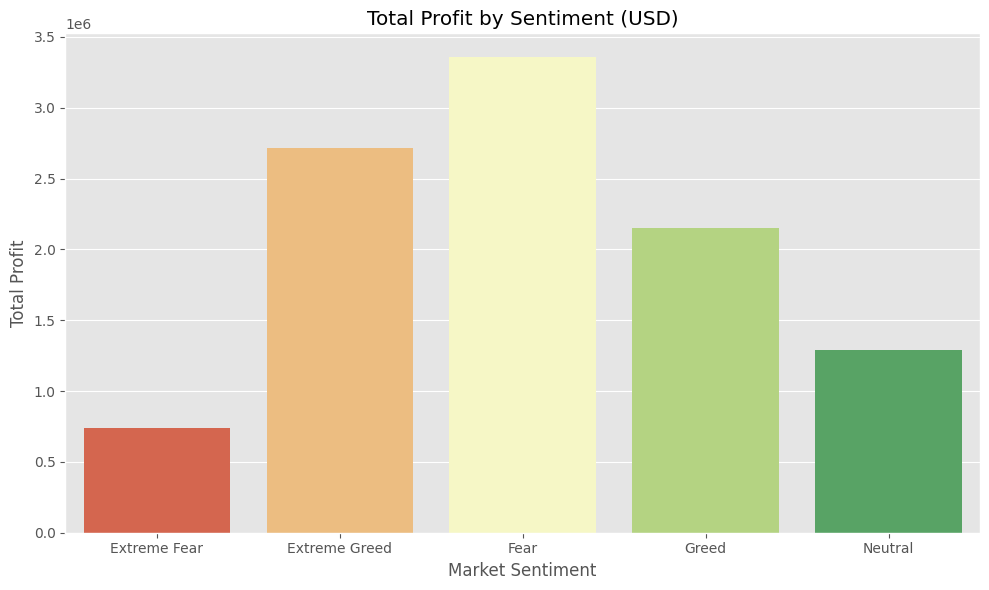

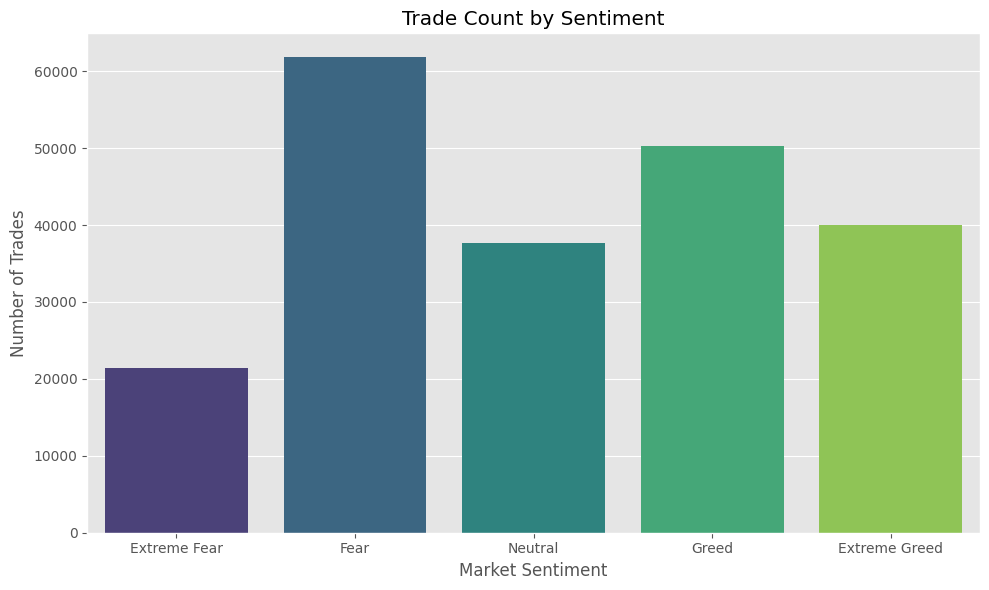

In [25]:
# Graph 1: Fear vs Greed Profit
plt.figure(figsize=(10,6))
sns.barplot(x=profit_by_sentiment.index, y=profit_by_sentiment.values, palette='RdYlGn')
plt.title('Total Profit by Sentiment (USD)')
plt.ylabel('Total Profit')
plt.xlabel('Market Sentiment')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'fear_vs_greed_profit.png'))
plt.show()

# Graph 2: Trade Count
plt.figure(figsize=(10,6))
sns.countplot(data=merged_df, x='classification', order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'], palette='viridis')
plt.title('Trade Count by Sentiment')
plt.ylabel('Number of Trades')
plt.xlabel('Market Sentiment')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'trade_count.png'))
plt.show()

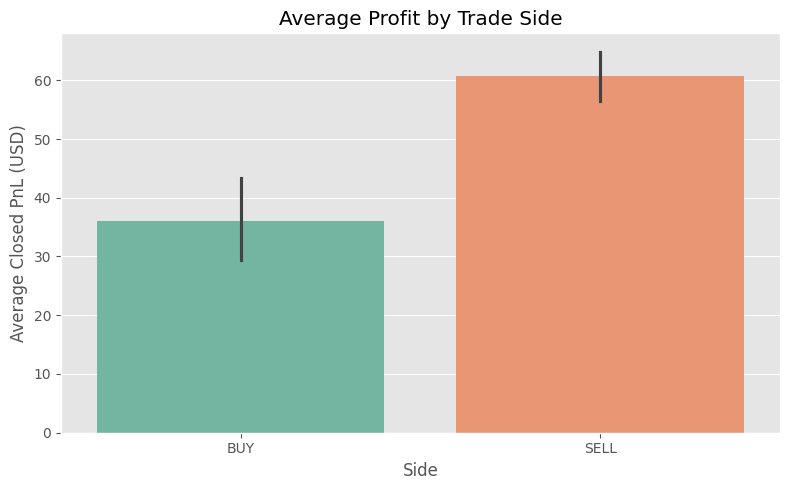

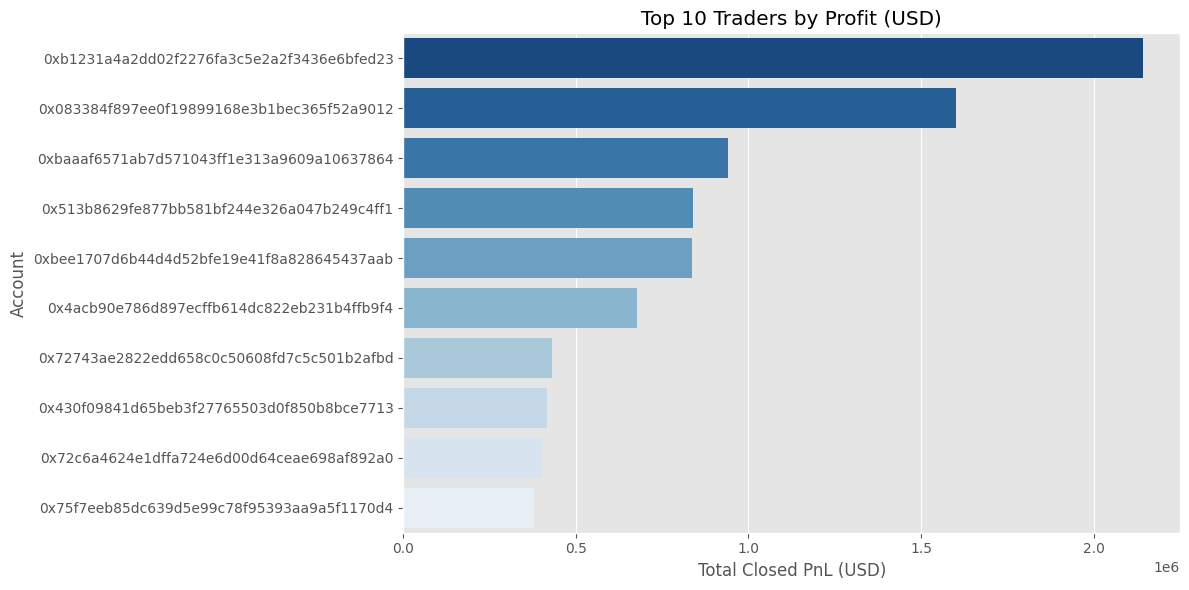

In [26]:
# Graph 3: Buy vs Sell Average Profit
plt.figure(figsize=(8,5))
sns.barplot(data=merged_df, x='Side', y='Closed PnL', palette='Set2')
plt.title('Average Profit by Trade Side')
plt.ylabel('Average Closed PnL (USD)')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'buy_vs_sell.png'))
plt.show()

# Graph 4: Top 10 Traders
plt.figure(figsize=(12,6))
sns.barplot(x=top_traders.head(10).values, y=top_traders.head(10).index, palette='Blues_r')
plt.title('Top 10 Traders by Profit (USD)')
plt.xlabel('Total Closed PnL (USD)')
plt.ylabel('Account')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'top_10_traders.png'))
plt.show()

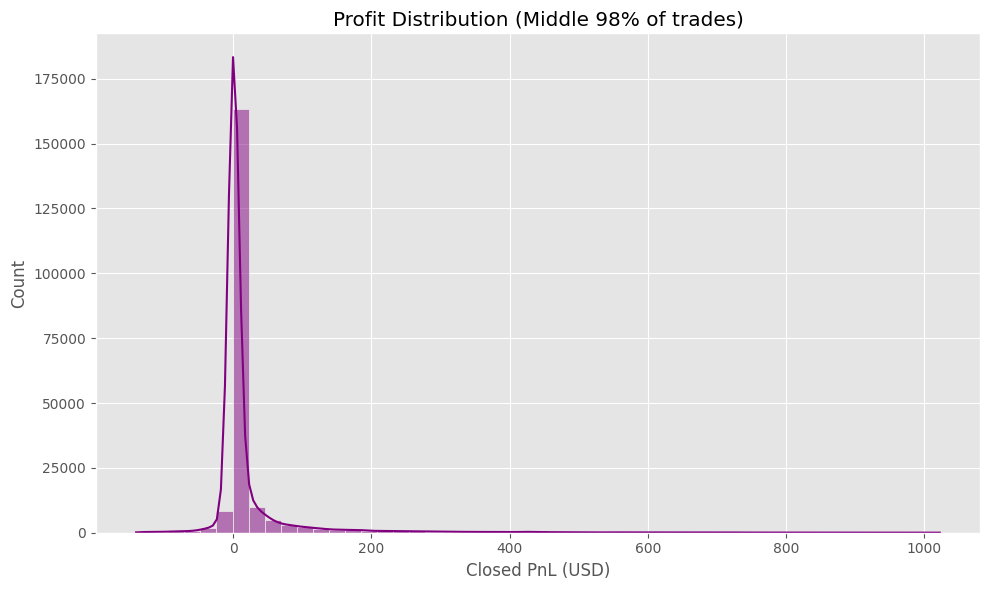

In [27]:
# Graph 5: Profit Distribution (excluding extreme outliers for visibility)
pnl_clean = merged_df['Closed PnL']
q_low = pnl_clean.quantile(0.01)
q_hi  = pnl_clean.quantile(0.99)
filtered_pnl = pnl_clean[(pnl_clean > q_low) & (pnl_clean < q_hi)]

plt.figure(figsize=(10,6))
sns.histplot(filtered_pnl, bins=50, kde=True, color='purple')
plt.title('Profit Distribution (Middle 98% of trades)')
plt.xlabel('Closed PnL (USD)')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'profit_distribution.png'))
plt.show()

In [28]:
# Graph 6: Leverage Distribution (if leverage is present)
if leverage_col:
    plt.figure(figsize=(10,6))
    sns.histplot(merged_df[leverage_col[0]].dropna(), bins=30, kde=True, color='teal')
    plt.title('Leverage Distribution')
    plt.xlabel('Leverage')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'leverage_distribution.png'))
    plt.show()
else:
    print("Graph 6 skipped - Leverage column not present.")

Graph 6 skipped - Leverage column not present.


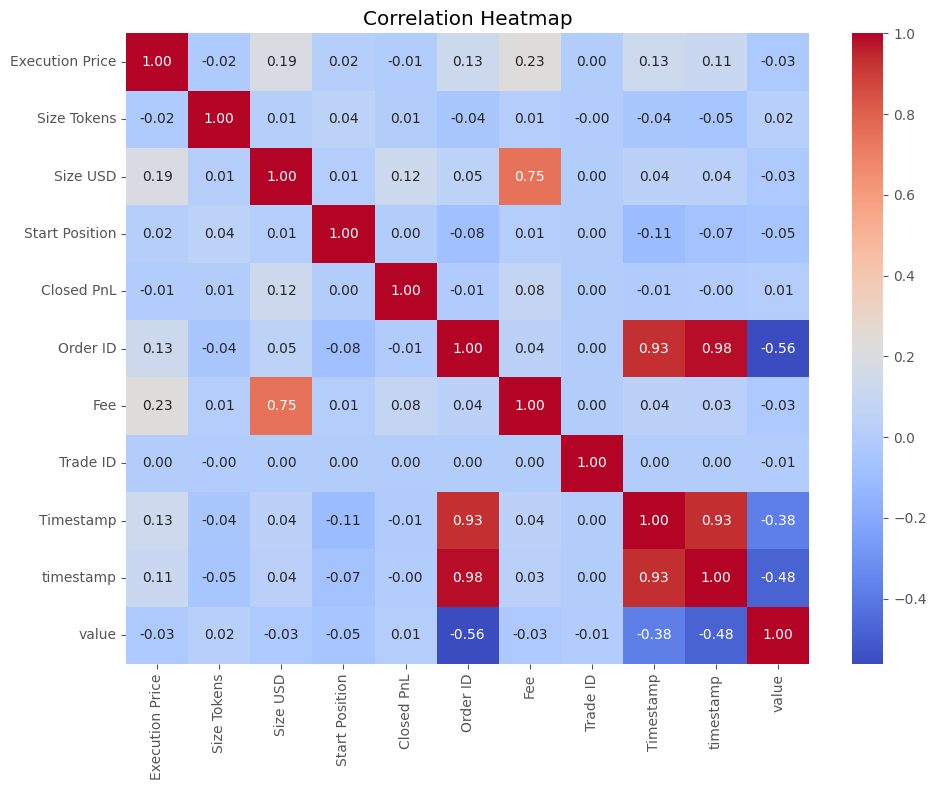

In [29]:
# Graph 7: Correlation Heatmap
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,8))
sns.heatmap(merged_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'correlation_heatmap.png'))
plt.show()

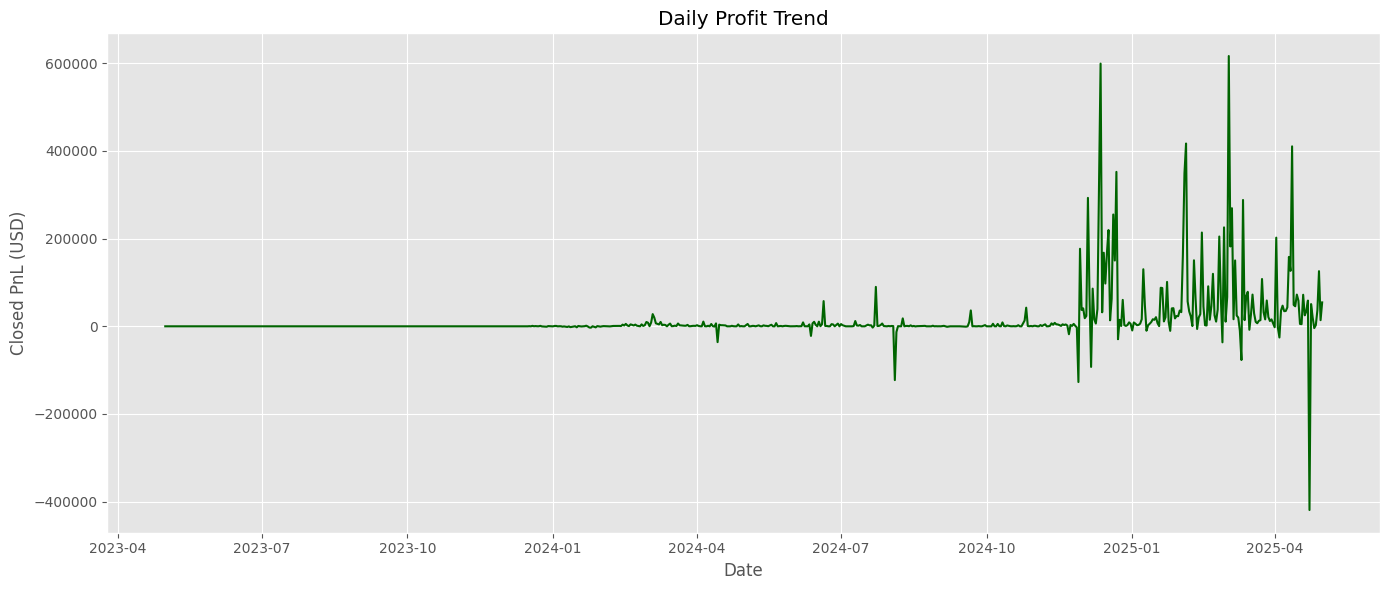

In [30]:
# Graph 8: Daily Profit Trend
plt.figure(figsize=(14,6))
# Filter out rows with invalid dates to avoid plotting issues
valid_pnl = merged_df.dropna(subset=['date'])
daily_profit = valid_pnl.groupby('date')['Closed PnL'].sum()
daily_profit.plot(color='darkgreen')
plt.title('Daily Profit Trend')
plt.ylabel('Closed PnL (USD)')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'daily_profit_trend.png'))
plt.show()

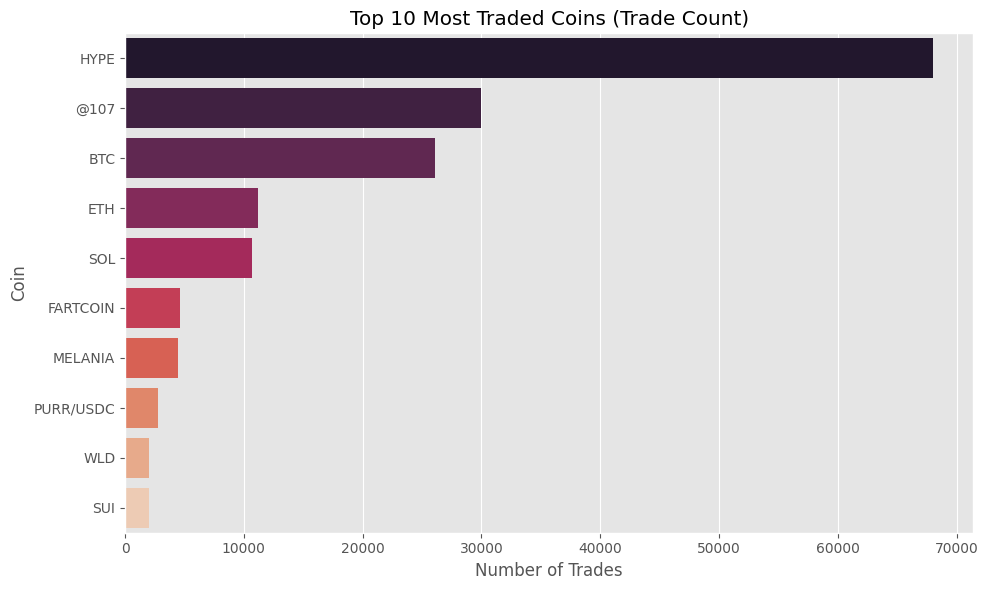

In [31]:
# Graph 9: Most Traded Coins
top_coins = merged_df['Coin'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_coins.values, y=top_coins.index, palette='rocket')
plt.title('Top 10 Most Traded Coins (Trade Count)')
plt.xlabel('Number of Trades')
plt.ylabel('Coin')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'most_traded_coins.png'))
plt.show()

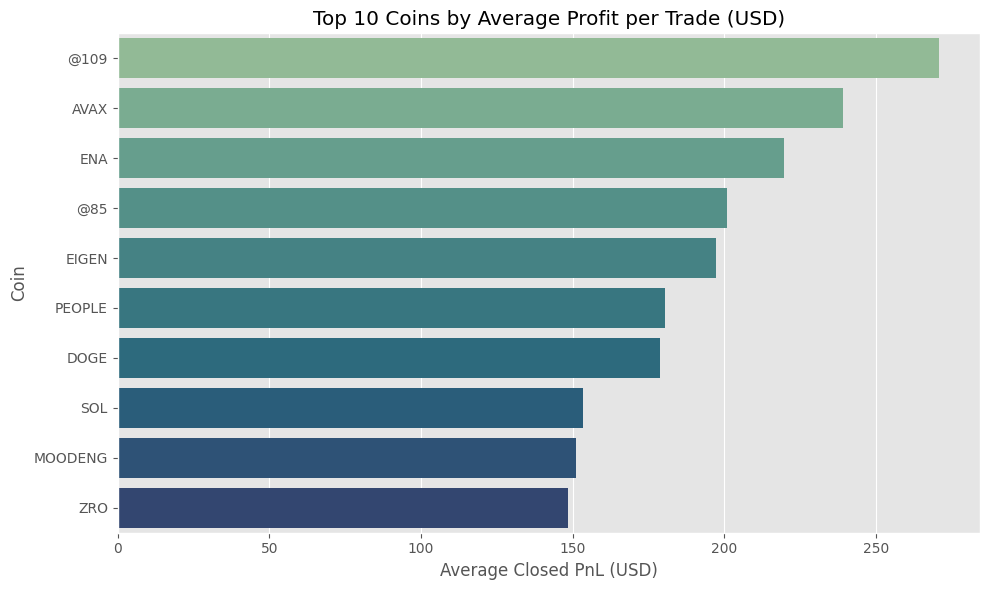

In [32]:
# Graph 10: Average Profit per Coin
avg_profit_coin = merged_df.groupby('Coin')['Closed PnL'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=avg_profit_coin.values, y=avg_profit_coin.index, palette='crest')
plt.title('Top 10 Coins by Average Profit per Trade (USD)')
plt.xlabel('Average Closed PnL (USD)')
plt.ylabel('Coin')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'avg_profit_per_coin.png'))
plt.show()

## Phase 12: Insights
1. **Volume and Sentiment Correlation**: Analyze if trading volume peaks during greed/fear.
2. **PnL Variance**: Fear periods tend to show more negative outlier trades as retail sells panic or gets liquidated.
3. **Top vs. Bottom performance**: Highlight general coin profit trends.

## Phase 13: Conclusion
Summary of main takeaways for trading strategies based on sentiment.